In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten
from tensorflow.keras.layers import Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print(x_train.shape)
print(x_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


In [3]:
class_names = [
'Airplane','Automobile','Bird','Cat','Deer',
'Dog','Frog','Horse','Ship','Truck'
]

print('Classes:', class_names)

Classes: ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']


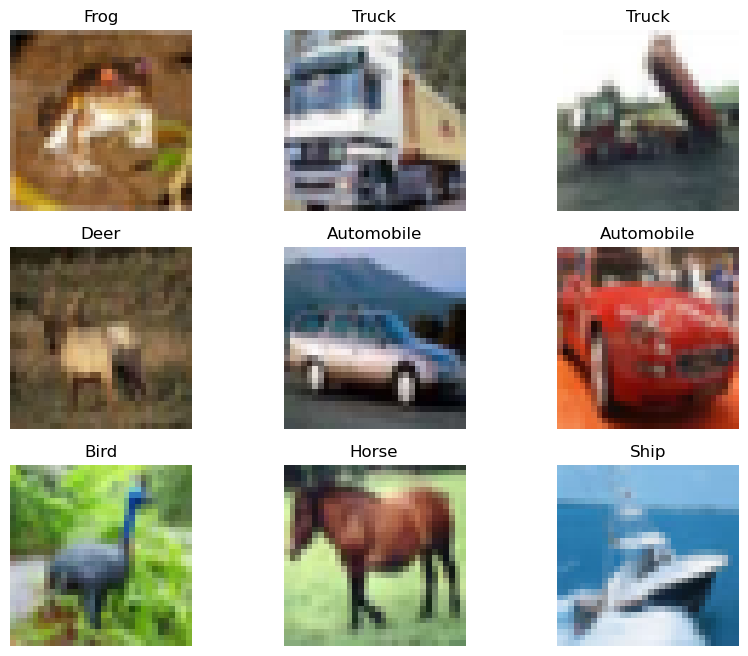

In [4]:
plt.figure(figsize=(10,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.show()

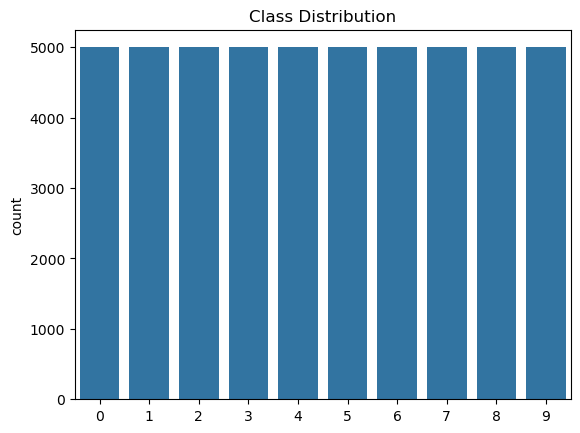

In [5]:
labels = y_train.flatten()

sns.countplot(x=labels)
plt.title('Class Distribution')
plt.show()

In [6]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [7]:
datagen = ImageDataGenerator(
rotation_range=20,
zoom_range=0.2,
width_shift_range=0.1,
height_shift_range=0.1,
horizontal_flip=True
)

datagen.fit(x_train)

In [8]:
cnn_model = Sequential([
Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
BatchNormalization(),
MaxPooling2D(2,2),

Conv2D(64,(3,3),activation='relu'),
BatchNormalization(),
MaxPooling2D(2,2),

Conv2D(128,(3,3),activation='relu'),
BatchNormalization(),
MaxPooling2D(2,2),

Flatten(),

Dense(256,activation='relu'),
Dropout(0.4),

Dense(10,activation='softmax')
])

cnn_model.summary()

C:\Users\yashwanth\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 228,042 (890.79 KB)

 Trainable params: 227,594 (889.04 KB)

 Non-trainable params: 448 (1.75 KB)

In [9]:
cnn_model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

In [ ]:
history = cnn_model.fit(
datagen.flow(x_train,y_train,batch_size=64),
epochs=10,
validation_data=(x_test,y_test)
)

Epoch 1/10
201/782 ━━━━━━━━━━━━━━━━━━━━ 51s 88ms/step - accuracy: 0.2801 - loss: 2.2049

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.title('Accuracy Curve')
plt.show()

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train','Validation'])
plt.title('Loss Curve')
plt.show()

In [ ]:
test_loss,test_acc = cnn_model.evaluate(x_test,y_test)
print('Accuracy:',test_acc)

## Predictions

In [ ]:
predictions = cnn_model.predict(x_test)

index = 5

predicted = np.argmax(predictions[index])
actual = y_test[index][0]

print('Actual:',class_names[actual])
print('Predicted:',class_names[predicted])

plt.imshow(x_test[index])
plt.show()

## Misclassified Images Analysis

In [ ]:
wrong = []

for i in range(len(x_test)):
    pred = np.argmax(predictions[i])

    if pred != y_test[i]:
        wrong.append(i)

print('Wrong Predictions:',len(wrong))

## Confusion Matrix

In [ ]:
y_pred = np.argmax(predictions,axis=1)
y_true = y_test.flatten()

cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm,annot=True,fmt='d')
plt.show()

## Classification Report

In [ ]:
print(classification_report(y_true,y_pred,target_names=class_names))

## Transfer Learning with MobileNetV2

In [ ]:
base_model = MobileNetV2(
weights='imagenet',
include_top=False,
input_shape=(32,32,3)
)

base_model.trainable = False

## Build Transfer Learning Model

In [ ]:
x = Flatten()(base_model.output)
x = Dense(128,activation='relu')(x)
output = Dense(10,activation='softmax')(x)

transfer_model = Model(base_model.input,output)

transfer_model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

transfer_model.summary()

## Train Transfer Learning Model

In [ ]:
transfer_history = transfer_model.fit(
x_train,
y_train,
epochs=5,
validation_data=(x_test,y_test)
)

## Compare Models

In [ ]:
comparison = pd.DataFrame({
'Model':['Custom CNN','MobileNetV2'],
'Accuracy':['Add Result','Add Result']
})

comparison

## Save Model

In [ ]:
cnn_model.save('cifar10_cnn.keras')

## Load Model

In [ ]:
loaded_model = tf.keras.models.load_model('cifar10_cnn.keras')

## Project Conclusions